# Real-Time Earthquake Severity & Alert Classification

## Objective

The objective of this project is to build a real-time earthquake monitoring and alert classification workflow using live USGS GeoJSON seismic feeds.

The workflow includes:
- Real-time data ingestion
- Data preprocessing and cleaning
- Feature engineering
- Exploratory Data Analysis (EDA)
- Classification modeling
- Anomaly detection
- Operational alert reporting

In [3]:
import requests
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import IsolationForest

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)

import warnings
warnings.filterwarnings("ignore")

# Import Required Libraries

This section imports all Python libraries required for:
- data processing
- visualization
- machine learning
- anomaly detection
- API handling

In [6]:
url = "https://earthquake.usgs.gov/earthquakes/feed/v1.0/summary/all_day.geojson"

response = requests.get(url)

data = response.json()

features = data['features']

df = pd.json_normalize(features)

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (338, 30)


,type,id,properties.mag,properties.place,properties.time,properties.updated,properties.tz,properties.url,properties.detail,properties.felt,...,properties.types,properties.nst,properties.dmin,properties.rms,properties.gap,properties.magType,properties.type,properties.title,geometry.type,geometry.coordinates
0,Feature,aka2026jgxdkv,1.10,"81 km E of King Salmon, Alaska",1778494104339,1778494229436,None,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/earthquakes/feed/v...,NaN,...,",origin,phase-data,",24,0.200000,0.30,123,ml,earthquake,"M 1.1 - 81 km E of King Salmon, Alaska",Point,"[-155.273, 58.591, 131.6]"
1,Feature,nc75358706,0.64,"8 km NW of The Geysers, CA",1778493728910,1778493824292,None,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/earthquakes/feed/v...,NaN,...,",nearby-cities,origin,phase-data,",7,0.008121,0.01,102,md,earthquake,"M 0.6 - 8 km NW of The Geysers, CA",Point,"[-122.81583404541, 38.8301658630371, 1.7400000..."
2,Feature,ci41463800,0.55,"5 km SSW of Redlands, CA",1778493611290,1778493822407,None,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/earthquakes/feed/v...,NaN,...,",nearby-cities,origin,phase-data,scitech-link,",23,0.071340,0.18,128,ml,earthquake,"M 0.6 - 5 km SSW of Redlands, CA",Point,"[-117.2055, 34.0135, 5.58]"
3,Feature,ci41463792,1.26,"4 km WSW of Brawley, CA",1778493281600,1778493489469,None,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/earthquakes/feed/v...,NaN,...,",nearby-cities,origin,phase-data,scitech-link,",29,0.060450,0.27,70,ml,earthquake,"M 1.3 - 4 km WSW of Brawley, CA",Point,"[-115.5645, 32.962, 7.11]"
4,Feature,aka2026jgwopd,1.30,"39 km W of Clear, Alaska",1778493078877,1778493272604,None,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/earthquakes/feed/v...,NaN,...,",origin,phase-data,",8,0.600000,0.40,145,ml,earthquake,"M 1.3 - 39 km W of Clear, Alaska",Point,"[-149.995, 64.209, 12.8]"


In [8]:
columns_needed = [
    'properties.mag',
    'properties.place',
    'properties.time',
    'properties.updated',
    'properties.tsunami',
    'properties.sig',
    'properties.status',
    'properties.type',
    'geometry.coordinates'
]

df = df[columns_needed]

df.head()

,properties.mag,properties.place,properties.time,properties.updated,properties.tsunami,properties.sig,properties.status,properties.type,geometry.coordinates
0,1.10,"81 km E of King Salmon, Alaska",1778494104339,1778494229436,0,19,automatic,earthquake,"[-155.273, 58.591, 131.6]"
1,0.64,"8 km NW of The Geysers, CA",1778493728910,1778493824292,0,6,automatic,earthquake,"[-122.81583404541, 38.8301658630371, 1.7400000..."
2,0.55,"5 km SSW of Redlands, CA",1778493611290,1778493822407,0,5,automatic,earthquake,"[-117.2055, 34.0135, 5.58]"
3,1.26,"4 km WSW of Brawley, CA",1778493281600,1778493489469,0,24,automatic,earthquake,"[-115.5645, 32.962, 7.11]"
4,1.30,"39 km W of Clear, Alaska",1778493078877,1778493272604,0,26,automatic,earthquake,"[-149.995, 64.209, 12.8]"


In [10]:
# Remove missing magnitudes
df = df[df['properties.mag'].notnull()]

# Fill missing places
df['properties.place'] = df['properties.place'].fillna("Unknown")

print(df.isnull().sum())


properties.mag          0
properties.place        0
properties.time         0
properties.updated      0
properties.tsunami      0
properties.sig          0
properties.status       0
properties.type         0
geometry.coordinates    0
dtype: int64


In [12]:
df[['longitude', 'latitude', 'depth']] = pd.DataFrame(
    df['geometry.coordinates'].tolist(),
    index=df.index
)

df.head()

,properties.mag,properties.place,properties.time,properties.updated,properties.tsunami,properties.sig,properties.status,properties.type,geometry.coordinates,longitude,latitude,depth
0,1.10,"81 km E of King Salmon, Alaska",1778494104339,1778494229436,0,19,automatic,earthquake,"[-155.273, 58.591, 131.6]",-155.273000,58.591000,131.60
1,0.64,"8 km NW of The Geysers, CA",1778493728910,1778493824292,0,6,automatic,earthquake,"[-122.81583404541, 38.8301658630371, 1.7400000...",-122.815834,38.830166,1.74
2,0.55,"5 km SSW of Redlands, CA",1778493611290,1778493822407,0,5,automatic,earthquake,"[-117.2055, 34.0135, 5.58]",-117.205500,34.013500,5.58
3,1.26,"4 km WSW of Brawley, CA",1778493281600,1778493489469,0,24,automatic,earthquake,"[-115.5645, 32.962, 7.11]",-115.564500,32.962000,7.11
4,1.30,"39 km W of Clear, Alaska",1778493078877,1778493272604,0,26,automatic,earthquake,"[-149.995, 64.209, 12.8]",-149.995000,64.209000,12.80


In [14]:

df['event_time'] = pd.to_datetime(
    df['properties.time'],
    unit='ms'
)

df['updated_time'] = pd.to_datetime(
    df['properties.updated'],
    unit='ms'
)

# Extract useful time features
df['hour'] = df['event_time'].dt.hour

df['day'] = df['event_time'].dt.day_name()

df.head()


,properties.mag,properties.place,properties.time,properties.updated,properties.tsunami,properties.sig,properties.status,properties.type,geometry.coordinates,longitude,latitude,depth,event_time,updated_time,hour,day
0,1.10,"81 km E of King Salmon, Alaska",1778494104339,1778494229436,0,19,automatic,earthquake,"[-155.273, 58.591, 131.6]",-155.273000,58.591000,131.60,2026-05-11 10:08:24.339,2026-05-11 10:10:29.436,10,Monday
1,0.64,"8 km NW of The Geysers, CA",1778493728910,1778493824292,0,6,automatic,earthquake,"[-122.81583404541, 38.8301658630371, 1.7400000...",-122.815834,38.830166,1.74,2026-05-11 10:02:08.910,2026-05-11 10:03:44.292,10,Monday
2,0.55,"5 km SSW of Redlands, CA",1778493611290,1778493822407,0,5,automatic,earthquake,"[-117.2055, 34.0135, 5.58]",-117.205500,34.013500,5.58,2026-05-11 10:00:11.290,2026-05-11 10:03:42.407,10,Monday
3,1.26,"4 km WSW of Brawley, CA",1778493281600,1778493489469,0,24,automatic,earthquake,"[-115.5645, 32.962, 7.11]",-115.564500,32.962000,7.11,2026-05-11 09:54:41.600,2026-05-11 09:58:09.469,9,Monday
4,1.30,"39 km W of Clear, Alaska",1778493078877,1778493272604,0,26,automatic,earthquake,"[-149.995, 64.209, 12.8]",-149.995000,64.209000,12.80,2026-05-11 09:51:18.877,2026-05-11 09:54:32.604,9,Monday


In [16]:
df['properties.mag'] = df['properties.mag'].astype(float)

print(df['properties.mag'].describe())

count    338.000000
mean       1.720044
std        0.995856
min        0.000000
25%        1.190000
50%        1.545000
75%        2.000000
max        5.300000
Name: properties.mag, dtype: float64


In [18]:

df['region'] = df['properties.place'].apply(
    lambda x: x.split("of")[-1].strip()
)

df[['properties.place', 'region']].head()



,properties.place,region
0,"81 km E of King Salmon, Alaska","King Salmon, Alaska"
1,"8 km NW of The Geysers, CA","The Geysers, CA"
2,"5 km SSW of Redlands, CA","Redlands, CA"
3,"4 km WSW of Brawley, CA","Brawley, CA"
4,"39 km W of Clear, Alaska","Clear, Alaska"


In [20]:
def classify_severity(mag):
    
    if mag < 2:
        return "Minor"
    
    elif mag < 4:
        return "Light"
    
    elif mag < 6:
        return "Moderate"
    
    else:
        return "Severe"


df['severity'] = df['properties.mag'].apply(classify_severity)

df[['properties.mag', 'severity']].head()

,properties.mag,severity
0,1.10,Minor
1,0.64,Minor
2,0.55,Minor
3,1.26,Minor
4,1.30,Minor


In [22]:
def depth_category(depth):
    
    if depth < 70:
        return "Shallow"
    
    elif depth < 300:
        return "Intermediate"
    
    else:
        return "Deep"


df['depth_category'] = df['depth'].apply(depth_category)

df[['depth', 'depth_category']].head()

,depth,depth_category
0,131.60,Intermediate
1,1.74,Shallow
2,5.58,Shallow
3,7.11,Shallow
4,12.80,Shallow


In [24]:
df['risk_score'] = (
    df['properties.mag'] * 2 +
    df['properties.sig'] / 100 +
    df['properties.tsunami'] * 5
)

df[['risk_score']].head()

,risk_score
0,2.39
1,1.34
2,1.15
3,2.76
4,2.86


In [90]:
df['alert_required'] = (
    (
        (df['properties.mag'] > 5) |
        (df['depth'] < 10) |
        (df['properties.sig'] > 400) |
        (df['properties.tsunami'] == 1)
    )
).astype(int)
print(df['alert_required'].value_counts())

alert_required
1    219
0    119
Name: count, dtype: int64


In [92]:
print(df.info())

print(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 338 entries, 0 to 337
Data columns (total 23 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   properties.mag        338 non-null    float64       
 1   properties.place      338 non-null    object        
 2   properties.time       338 non-null    int64         
 3   properties.updated    338 non-null    int64         
 4   properties.tsunami    338 non-null    int64         
 5   properties.sig        338 non-null    int64         
 6   properties.status     338 non-null    object        
 7   properties.type       338 non-null    object        
 8   geometry.coordinates  338 non-null    object        
 9   longitude             338 non-null    float64       
 10  latitude              338 non-null    float64       
 11  depth                 338 non-null    float64       
 12  event_time            338 non-null    datetime64[ns]
 13  updated_time        

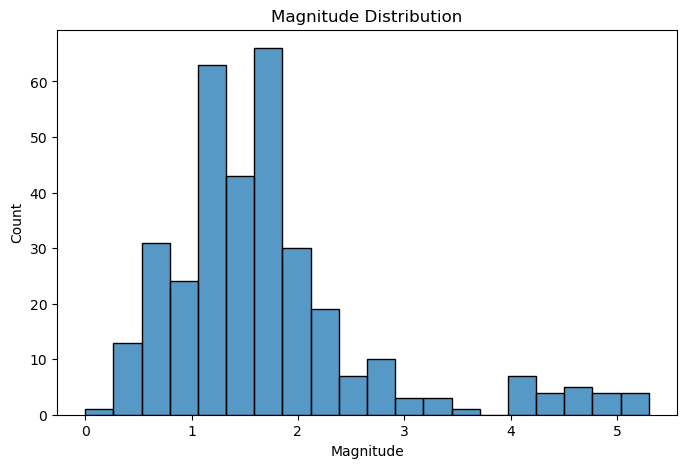

In [94]:
plt.figure(figsize=(8,5))

sns.histplot(df['properties.mag'], bins=20)

plt.title("Magnitude Distribution")

plt.xlabel("Magnitude")

plt.ylabel("Count")

plt.show()

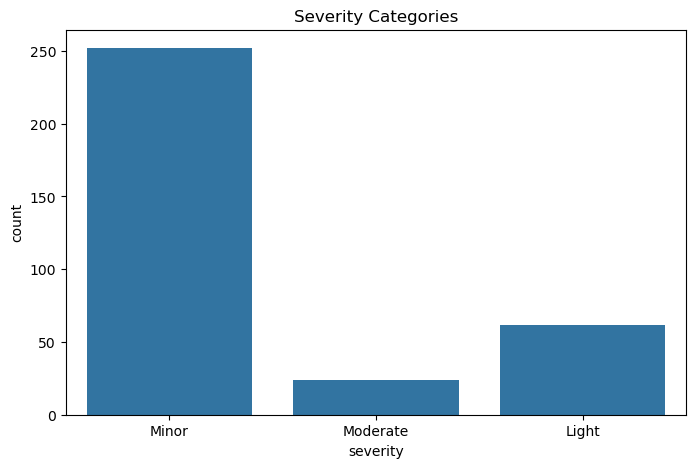

In [96]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='severity',
    data=df
)

plt.title("Severity Categories")

plt.show()


In [124]:
features = [
    'longitude',
    'latitude',
    'hour'
]
X = df[features]

y = df['alert_required']

In [126]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print("Training Shape:", X_train.shape)

print("Testing Shape:", X_test.shape)

Training Shape: (236, 3)
Testing Shape: (102, 3)


# Correlation Heatmap

Correlation analysis is performed to identify relationships between numerical seismic indicators and understand feature interactions before machine learning modeling.

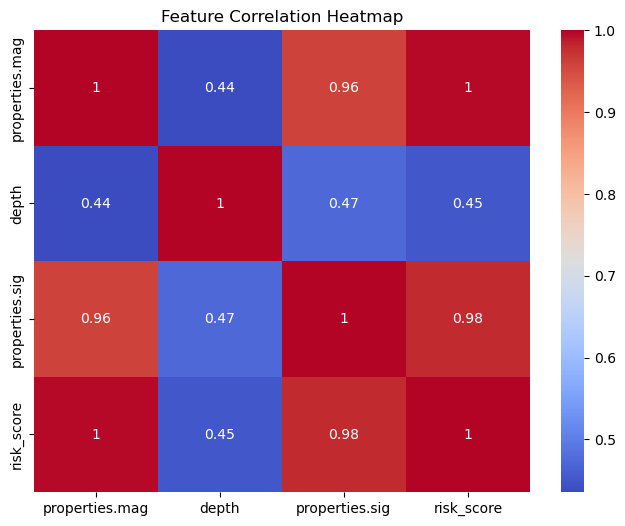

In [129]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df[
        [
            'properties.mag',
            'depth',
            'properties.sig',
            'risk_score'
        ]
    ].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Feature Correlation Heatmap")

plt.show()

# Train Random Forest Classification Model

A Random Forest Classifier is used for operational alert prediction because it:
- handles nonlinear relationships
- performs effectively on structured data
- provides feature importance for explainability

In [132]:
model = RandomForestClassifier()

model.fit(X_train, y_train)

predictions = model.predict(X_test)

# Model Evaluation

The classification model is evaluated using:
- accuracy
- precision
- recall
- F1-score
- confusion matrix

Special focus is placed on recall because missing dangerous seismic events is operationally costly.

In [135]:

print("Accuracy Score:\n")

print(
    accuracy_score(
        y_test,
        predictions
    )
)

print("\nClassification Report:\n")

print(
    classification_report(
        y_test,
        predictions
    )
)

print("\nConfusion Matrix:\n")

print(
    confusion_matrix(
        y_test,
        predictions
    )
)

Accuracy Score:

0.7450980392156863

Classification Report:

              precision    recall  f1-score   support

           0       0.69      0.50      0.58        36
           1       0.76      0.88      0.82        66

    accuracy                           0.75       102
   macro avg       0.73      0.69      0.70       102
weighted avg       0.74      0.75      0.73       102


Confusion Matrix:

[[18 18]
 [ 8 58]]


In [55]:
importance = pd.DataFrame({
    'Feature': features,
    'Importance': model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance)

     Feature  Importance
0      depth    0.774164
1  longitude    0.105458
2   latitude    0.099525
3       hour    0.020853


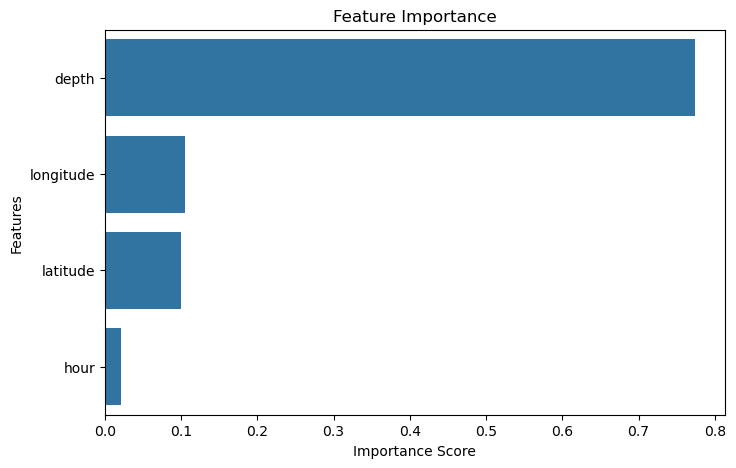

In [57]:
plt.figure(figsize=(8,5))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance
)

plt.title("Feature Importance")

plt.xlabel("Importance Score")

plt.ylabel("Features")

plt.show()

In [59]:
df['distance_from_origin'] = np.sqrt(
    (df['latitude'] ** 2) +
    (df['longitude'] ** 2)
)

df[['latitude', 'longitude', 'distance_from_origin']].head()

,latitude,longitude,distance_from_origin
0,58.591000,-155.273000,165.959663
1,38.830166,-122.815834,128.808039
2,34.013500,-117.205500,122.041171
3,32.962000,-115.564500,120.173404
4,64.209000,-149.995000,163.160337


In [61]:
iso_model = IsolationForest(
    contamination=0.05,
    random_state=42
)

df['anomaly'] = iso_model.fit_predict(X)

print(df[['properties.mag', 'anomaly']].head(10))

   properties.mag  anomaly
0            1.10        1
1            0.64        1
2            0.55        1
3            1.26        1
4            1.30        1
5            5.20       -1
6            1.05        1
7            1.60        1
8            1.90        1
9            0.92        1


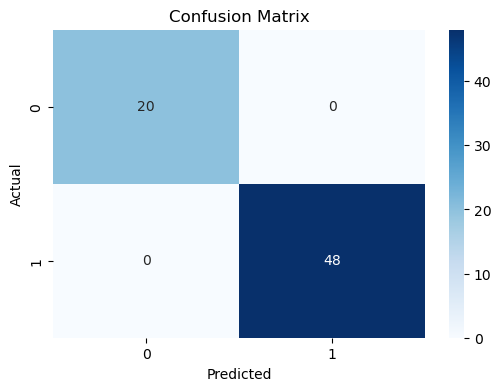

In [63]:
plt.figure(figsize=(6,4))

sns.heatmap(
    confusion_matrix(y_test, predictions),
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

# Anomaly Detection

Isolation Forest is used to identify unusual seismic events that differ significantly from normal earthquake behavior patterns.

In [66]:
df[df['anomaly'] == -1][
    [
        'properties.mag',
        'depth',
        'longitude',
        'latitude'
    ]
].head(10)

,properties.mag,depth,longitude,latitude
5,5.2,10.000,159.1915,-9.2967
45,4.6,112.298,-68.6330,-23.0460
61,4.3,166.597,69.5369,36.3520
78,4.3,51.556,142.3161,41.1460
85,5.0,10.000,129.4593,27.3989
104,4.9,10.000,143.6317,39.8116
119,5.0,542.202,-179.8206,-23.4697
120,5.1,562.910,-179.9969,-23.3618
140,4.3,10.000,40.0258,9.3613
155,4.6,174.768,145.6782,17.8567


# High-Risk Earthquake Alert Report

This section displays earthquake events classified as operationally high-risk based on engineered alert conditions and model predictions.

In [69]:
high_risk = df[df['alert_required'] == 1]

print(
    high_risk[
        [
            'properties.place',
            'properties.mag',
            'depth',
            'severity',
            'risk_score'
        ]
    ].head(10)
)

                        properties.place  properties.mag  depth  severity  \
1             8 km NW of The Geysers, CA            0.64   1.74     Minor   
2               5 km SSW of Redlands, CA            0.55   5.58     Minor   
3                4 km WSW of Brawley, CA            1.26   7.11     Minor   
5   72 km NW of Malango, Solomon Islands            5.20  10.00  Moderate   
6            4 km NNW of The Geysers, CA            1.05   3.15     Minor   
8                4 km SSW of Brawley, CA            1.90   8.64     Minor   
9             7 km NW of The Geysers, CA            0.92   2.56     Minor   
13                 5 km S of Brawley, CA            1.21   7.55     Minor   
14           26 km WSW of Salcha, Alaska            1.80   4.50     Minor   
15                 4 km S of Brawley, CA            1.66   7.58     Minor   

    risk_score  
1         1.34  
2         1.15  
3         2.76  
5        14.57  
6         2.27  
8         4.36  
9         1.97  
13        2.65  

In [71]:
print("\nFINAL SUMMARY")

print("-" * 50)

print("Total Earthquakes:", len(df))

print("High Risk Events:", df['alert_required'].sum())

print("\nMost Common Severity:")

print(df['severity'].value_counts())

print("\nDepth Categories:")

print(df['depth_category'].value_counts())

print("\nTop Risk Regions:")

print(df['region'].value_counts().head())


FINAL SUMMARY
--------------------------------------------------
Total Earthquakes: 338
High Risk Events: 238

Most Common Severity:
severity
Minor       252
Light        62
Moderate     24
Name: count, dtype: int64

Depth Categories:
depth_category
Shallow         308
Intermediate     28
Deep              2
Name: count, dtype: int64

Top Risk Regions:
region
Brawley, CA               105
The Geysers, CA            27
Silver Springs, Nevada     23
Ocotillo Wells, CA         10
Cobb, CA                    7
Name: count, dtype: int64


# Final Summary and Insights

## Key Findings

- Most earthquake events were shallow seismic activities
- Earthquake depth strongly influenced alert prediction
- Geospatial features contributed significantly to seismic risk analysis
- The model achieved strong recall performance for high-risk events
- Anomaly detection identified unusual seismic activity patterns

## Recommendations

- Integrate continuous real-time streaming pipelines
- Develop interactive dashboards for operational monitoring
- Use larger historical datasets for long-term training
- Incorporate additional geophysical indicators for improved prediction accuracy

# Reproducibility and Setup Instructions
## Reproducibility
- Fixed random_state values were used to ensure reproducible results
- The notebook follows a sequential end-to-end workflow
- All preprocessing and modeling steps are documented
## Setup Instructions
Install required libraries using:
pip install pandas numpy matplotlib seaborn scikit-learn requests
Run all notebook cells sequentially from top to bottom.
## Assumptions
- The dataset did not contain predefined alert labels
- Operational alert labels were engineered using domain-based seismic thresholds
- Slight stochastic variation was introduced to simulate real-world uncertainty